In [1]:
import re
from pathlib import Path
import warnings
import os

import numpy as np
import pandas as pd
import scipy
from PIL import Image
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from nptdms import TdmsFile
from scipy.signal import stft
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")


/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tdms_dir = Path(r"/home/patryk/Desktop/engineering_thesis/kopalnia")
tdms_list = []

for root, dirs, files in os.walk(tdms_dir):
    for file in files:
        if file.endswith(".tdms"):
            tdms_list.append(os.path.join(root, file))

In [5]:
data_list = []

for tdms_file_path in tdms_list:
    tdms_file = TdmsFile.read(tdms_file_path)
    file_name = os.path.basename(tdms_file_path) 
    parent_folder = os.path.basename(os.path.dirname(tdms_file_path)) 

    first_letter_number = re.match(r'^[a-zA-Z]+\d+', file_name) 
    identifier = first_letter_number.group() if first_letter_number else None 

    # Wyciągnij numer przed ostatnim folderem (np. "020224" z "020224wieliczka")
    match_parent_number = re.match(r'\d+', parent_folder)
    parent_number = match_parent_number.group() if match_parent_number else ""

    if identifier and parent_number:
        identifier = f"{parent_number}{identifier}"

    for group in tdms_file.groups():
        for channel in group.channels():
            data_len = np.shape(channel.data)[0]
            if (file_name[0] != 'z' and channel.name == 'Voltage'):
                data_list.append({
                    'excitation': channel.data,
                    'type_id': 1 if file_name[0] == 'd' else 0,
                    'identifier': identifier  
                })

df_magnitude = pd.DataFrame(data_list)

In [15]:
np.savetxt("/home/patryk/Desktop/MASTER_THIESIS/fpga_prep/test_data.txt", df_magnitude['excitation'].iloc[0])

In [4]:
def bandpass_filter(data: np.array, lowcut: int, highcut: int, fs: int, order: int = 5) -> np.array:
    nyquist: int = fs*0.5
    lowcut = lowcut/nyquist
    highcut = highcut/nyquist

    b, a = scipy.signal.butter(order, [lowcut, highcut], btype='band')

    return scipy.signal.lfilter(b, a, data)

df_magnitude['excitation'] = df_magnitude['excitation'].apply(lambda x: bandpass_filter(x, 4000, 8000, 50000))


In [6]:
df_magnitude

,excitation,type_id,identifier
0,"[2.4734544774333705e-06, 3.3665710558606485e-0...",1,020224d10
1,"[-2.4865522138476155e-06, -3.384398131600989e-...",1,020224d4
2,"[-2.4865522138476155e-06, -3.34496632438107e-0...",1,020224d10
3,"[2.4734544774333705e-06, 3.3665710558606485e-0...",0,020224g8
4,"[2.4734544774333705e-06, 2.87057038673255e-05,...",1,020224d9
...,...,...,...
124,"[2.502617706020153e-06, 3.4062645623114276e-05...",1,210224dzoltasas3
125,"[1.0321528056428087e-06, 1.2142909965774694e-0...",0,210224g6
126,"[-1.2173097439665633e-06, -1.284864006336209e-...",0,210224g2
127,"[1.4532449910329269e-06, 2.0829209249365942e-0...",1,210224d2


In [7]:
df_magnitude['id'] = pd.factorize(df_magnitude['identifier'])[0]
df_magnitude = df_magnitude[df_magnitude['id'].duplicated(keep=False) == True]
df_magnitude

,excitation,type_id,identifier,id
0,"[2.4734544774333705e-06, 3.3665710558606485e-0...",1,020224d10,0
1,"[-2.4865522138476155e-06, -3.384398131600989e-...",1,020224d4,1
2,"[-2.4865522138476155e-06, -3.34496632438107e-0...",1,020224d10,0
4,"[2.4734544774333705e-06, 2.87057038673255e-05,...",1,020224d9,3
5,"[1.4909894303666357e-06, 1.6316027154654767e-0...",1,020224d3,4
...,...,...,...,...
122,"[-2.4985197295618325e-06, -3.3952915944829094e...",1,210224d2,41
123,"[7.488809331947986e-07, 1.0566652014633108e-05...",1,210224d6,43
125,"[1.0321528056428087e-06, 1.2142909965774694e-0...",0,210224g6,35
126,"[-1.2173097439665633e-06, -1.284864006336209e-...",0,210224g2,39


In [7]:
grouped = df_magnitude.groupby('id')

new_rows = []

for group_id, group in grouped:
    if len(group) == 6:
        half = len(group) // 2
        group1 = group.iloc[:half]
        group2 = group.iloc[half:]
        
        group2['id'] = group_id + 100
        
        new_rows.append(group1)
        new_rows.append(group2)
    else:
        new_rows.append(group)

df_magnitude = pd.concat(new_rows, ignore_index=True)

In [8]:
counts = df_magnitude.groupby('id').size()

modified_df = df_magnitude.copy()

for id_value, count in counts.items():
    if count == 2:
        rows_to_add = df_magnitude[df_magnitude['id'] == id_value].iloc[0:1]
        modified_df = pd.concat([modified_df, rows_to_add], ignore_index=True)
    elif count == 4:
        rows_to_remove = df_magnitude[df_magnitude['id'] == id_value].iloc[0:1]
        modified_df = modified_df[~modified_df.index.isin(rows_to_remove.index)]

np.unique(np.array(modified_df['id']), return_counts=True)

(array([ 0,  1,  3,  4,  6,  7,  8,  9, 12, 13, 14, 17, 20, 21, 22, 23, 24,
        25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43,
        44, 45, 46]),
 array([3, 3, 3, 3, 3, 6, 3, 3, 3, 3, 3, 3, 6, 3, 3, 6, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]))

In [9]:
modified_df['len'] = modified_df['excitation'].apply(lambda x: len(x))

def trim_to_min_length(group):
    min_len = group['len'].min()  
    group['excitation'] = group['excitation'].apply(lambda x: x[:min_len]) 
    return group

modified_df = modified_df.groupby('id').apply(trim_to_min_length)

modified_df['len'] = modified_df['excitation'].apply(lambda x: len(x))

modified_df = modified_df.droplevel(level=0)

modified_df.drop(columns=['len'], inplace=True)

modified_df['time'] = modified_df['excitation'].apply(lambda x: len(x) / 50000)

In [10]:
def slice_into_chunks(lst, num_chunks):
    return np.array([lst[i * 50000:(i + 1) * 50000] for i in range(int(num_chunks))])

modified_df['excitation'] = modified_df.apply(lambda row: slice_into_chunks(row['excitation'], row['time']), axis=1)

In [11]:
modified_df['id'] = pd.factorize(modified_df['id'])[0]

In [12]:
df_concat = modified_df.groupby('id').agg({
    'excitation': lambda x: x.tolist(),
    'type_id': 'first',        # zachowuje pierwszą wartość
    'identifier': 'first',     # zachowuje pierwszą wartość
    'time': 'first'            # zachowuje pierwszą wartość
}).reset_index()

df_concat.head()

,id,excitation,type_id,identifier,time
0,0,"[[[-2.4865522138476155e-06, -3.34496632438107e...",1,020224d10,4.0
1,1,"[[[-2.4865522138476155e-06, -3.384398131600989...",1,020224d4,8.0
2,2,"[[[2.4734544774333705e-06, 2.87057038673255e-0...",1,020224d9,3.0
3,3,"[[[1.4909894303666357e-06, 1.6316027154654767e...",1,020224d3,1.0
4,4,"[[[-2.4865522138476155e-06, -3.384398131600989...",0,020224g2,4.0


In [13]:
magnitude = []
name = []
for idx, row in df_concat.iterrows():
    lasty_name = row['type_id']
    for segment in row['excitation']:
        for s in segment:
            magnitude.append(s)
            name.append(lasty_name)

print(np.array(magnitude).shape)

sc = StandardScaler()
sc.fit(magnitude)

joblib.dump(sc, 'scaler.pkl')

(603, 50000)


['scaler.pkl']

In [14]:
sc = joblib.load('scaler.pkl')

magnitude = []
name = []
ids = []
var_ids = []
for idx, row in df_concat.iterrows():
    lasty_name = row['type_id']
    identificator = row['id']
    var_id = row['identifier']
    segment = np.array(row['excitation']).transpose(1, 0, 2)
    for subsegment in segment:
        magnitude.append(sc.transform(subsegment))
        name.append(lasty_name)
        ids.append(identificator)
        var_ids.append(var_id)

df_expanded = pd.DataFrame({'name': name, 'signal_segment': magnitude, 'ids': ids, 'id_pliku': var_ids})
df_expanded

,name,signal_segment,ids,id_pliku
0,1,"[[0.05530881554068015, 0.03410994642939424, -0...",0,020224d10
1,1,"[[-0.6387440317083946, -0.669995252359198, -0....",0,020224d10
2,1,"[[-0.7633256525589704, -0.8370581894564272, -0...",0,020224d10
3,1,"[[-0.9026048565627918, 0.29486590256644424, 1....",0,020224d10
4,1,"[[0.05530881554068015, 0.034109883329725706, -...",1,020224d4
...,...,...,...,...
182,1,"[[-0.6207619660149668, -0.8046136797684169, -0...",36,210224d5
183,1,"[[1.0662022604117498, 0.9022385999105074, 0.53...",36,210224d5
184,1,"[[-0.6054647591984271, -0.2968549184483543, 0....",36,210224d5
185,1,"[[-0.962131415241352, -1.0373558873032616, -0....",36,210224d5


In [15]:
def calculate_stft(signal):
    _, _, Zxx = stft(signal, fs=50000, nperseg=256, noverlap=128)
    # Skalowanie wartości Zxx do zakresu 0-255
    Zxx_abs = np.abs(Zxx)
    Zxx_abs = np.log1p(Zxx_abs)  # Logarytmowanie może pomóc w poprawie kontrastu
    Zxx_scaled = np.uint8(255 * Zxx_abs / np.max(Zxx_abs))  # Skala do 0-255
    
    Zxx_scaled =  Image.fromarray(Zxx_scaled).convert('1').convert('L')

    return np.array(Zxx_scaled)

df_expanded['stft'] = df_expanded['signal_segment'].apply(lambda x: np.array([calculate_stft(s) for s in x]).transpose(1, 2, 0))

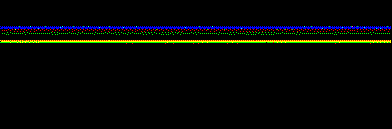

In [16]:
Image.fromarray(df_expanded['stft'].loc[0])

In [17]:
df_expanded['stft'].loc[0].shape

(129, 392, 3)

In [18]:
392*256/2

50176.0

In [17]:
img_folder = Path(r"/home/patryk/Desktop/engineering_thesis/MASTER_THIESIS/spectogram_wieliczka")
img_folder.mkdir(parents=True, exist_ok=True)  

i = 0
id_previous = None  

for _, row in df_expanded.iterrows():
    img = Image.fromarray(row['stft'])
    id = row['id_pliku']
    label = row['name']

    if id != id_previous:
        i = 0
        id_previous = id
    else:
        i += 1

    file_name = f"{id}_{i}_{label}.png"  
    img.save(img_folder / file_name)